# Sanity check: SMR equilibrium

This notebook computes the equilibrium composition of a CH4/H2O mixture at 850 °C, 25 bar and a steam-to-carbon ratio of 3 using the GRI-Mech 3.0 mechanism shipped with Cantera. The result is the thermodynamic ceiling for hydrogen yield at these conditions and serves as a quick check that the Cantera installation works.

In [1]:
import cantera as ct

T_C = 850.0          # °C
P = 25e5             # Pa
SC = 3.0             # steam-to-carbon ratio

gas = ct.Solution("gri30.yaml")
gas.TPX = T_C + 273.15, P, {"CH4": 1.0, "H2O": SC}

# Moles fed per mole of CH4 and mean molecular weight of the feed
n_in = 1.0 + SC
mw_in = gas.mean_molecular_weight

gas.equilibrate("TP")

# Mass is conserved, so total moles scale with the inverse of the mean MW
n_eq = n_in * mw_in / gas.mean_molecular_weight
X = gas.mole_fraction_dict()

species = ["H2", "CO", "CO2", "CH4", "H2O"]
print(f"Equilibrium at {T_C:.0f} °C, {P/1e5:.0f} bar, S/C = {SC:.0f} (GRI-Mech 3.0)")
print(f"{'Species':<8}{'Wet basis / %':>16}")
for s in species:
    print(f"{s:<8}{100*X[s]:>16.2f}")

x_h2_dry = X["H2"] / (1.0 - X["H2O"])
n_ch4_eq = X["CH4"] * n_eq
conversion = 1.0 - n_ch4_eq / 1.0

print()
print(f"Dry-basis H2 fraction : {100*x_h2_dry:.2f} %")
print(f"CH4 conversion        : {100*conversion:.2f} %")


Equilibrium at 850 °C, 25 bar, S/C = 3 (GRI-Mech 3.0)
Species    Wet basis / %
H2                 48.54
CO                  8.77
CO2                 5.56
CH4                 3.51
H2O                33.62

Dry-basis H2 fraction : 73.13 %
CH4 conversion        : 80.34 %


Saved figure to /Users/izbassar/Documents/Projects/reformer-digital-twin/paper/figures/fig00_equilibrium_conversion.png


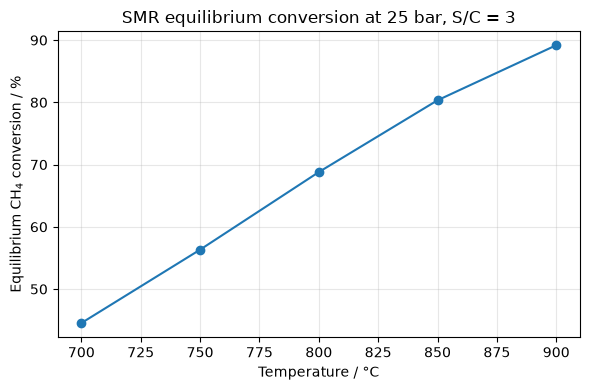

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

temps_C = np.array([700.0, 750.0, 800.0, 850.0, 900.0])
conversions = []

for T in temps_C:
    gas.TPX = T + 273.15, P, {"CH4": 1.0, "H2O": SC}
    mw_in = gas.mean_molecular_weight
    gas.equilibrate("TP")
    n_eq = n_in * mw_in / gas.mean_molecular_weight
    conversions.append(1.0 - gas.X[gas.species_index("CH4")] * n_eq)

conversions = np.array(conversions)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(temps_C, 100 * conversions, marker="o")
ax.set_xlabel("Temperature / °C")
ax.set_ylabel("Equilibrium CH$_4$ conversion / %")
ax.set_title(f"SMR equilibrium conversion at {P/1e5:.0f} bar, S/C = {SC:.0f}")
ax.grid(True, alpha=0.3)
fig.tight_layout()

out = Path("..") / "paper" / "figures" / "fig00_equilibrium_conversion.png"
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, dpi=150)
print(f"Saved figure to {out.resolve()}")
plt.show()
